In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use("ggplot")

In [54]:
scores = np.load("/content/feature_importances.npy")
idx = np.load("/content/feature_ranking_idx.npy")

Best validation result:
  top_k   = 1380
  lambda  = 1.0
  val_acc = 0.89534

Test set results with best configuration:
Lambda: 1.00000, Train Acc: 0.93899, Test Acc: 0.49250, Precision: 0.49584, Recall: 0.49250, F1: 0.45691

In [55]:
selected_idx = idx[:1380]
selected_idx = np.sort(selected_idx)

In [56]:
rows = []

for idx in selected_idx:
    rows.append({
        "global_index": idx,
        "sensor_id": idx // 60,
        "feature_method": idx % 60
    })

df_long = pd.DataFrame(rows)

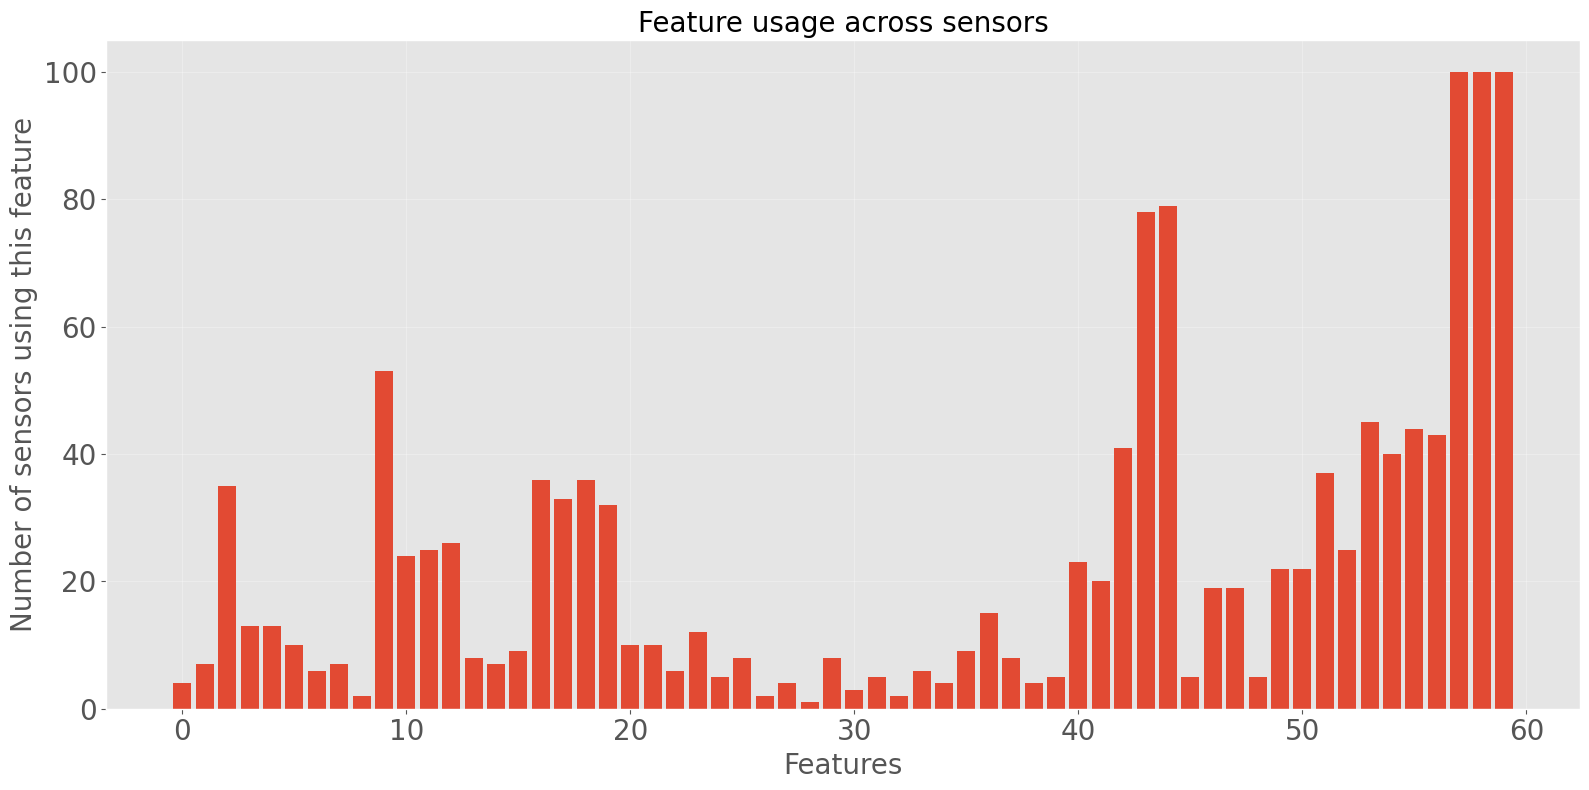

In [57]:
method_sensor_count = (
    df_long
    .groupby("feature_method")["sensor_id"]
    .nunique()
)

plt.figure(figsize=(16, 8))
plt.bar(method_sensor_count.index, method_sensor_count.values)
plt.xlabel("Features", fontsize=20)
plt.ylabel("Number of sensors using this feature", fontsize=20)
plt.title("Feature usage across sensors", fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

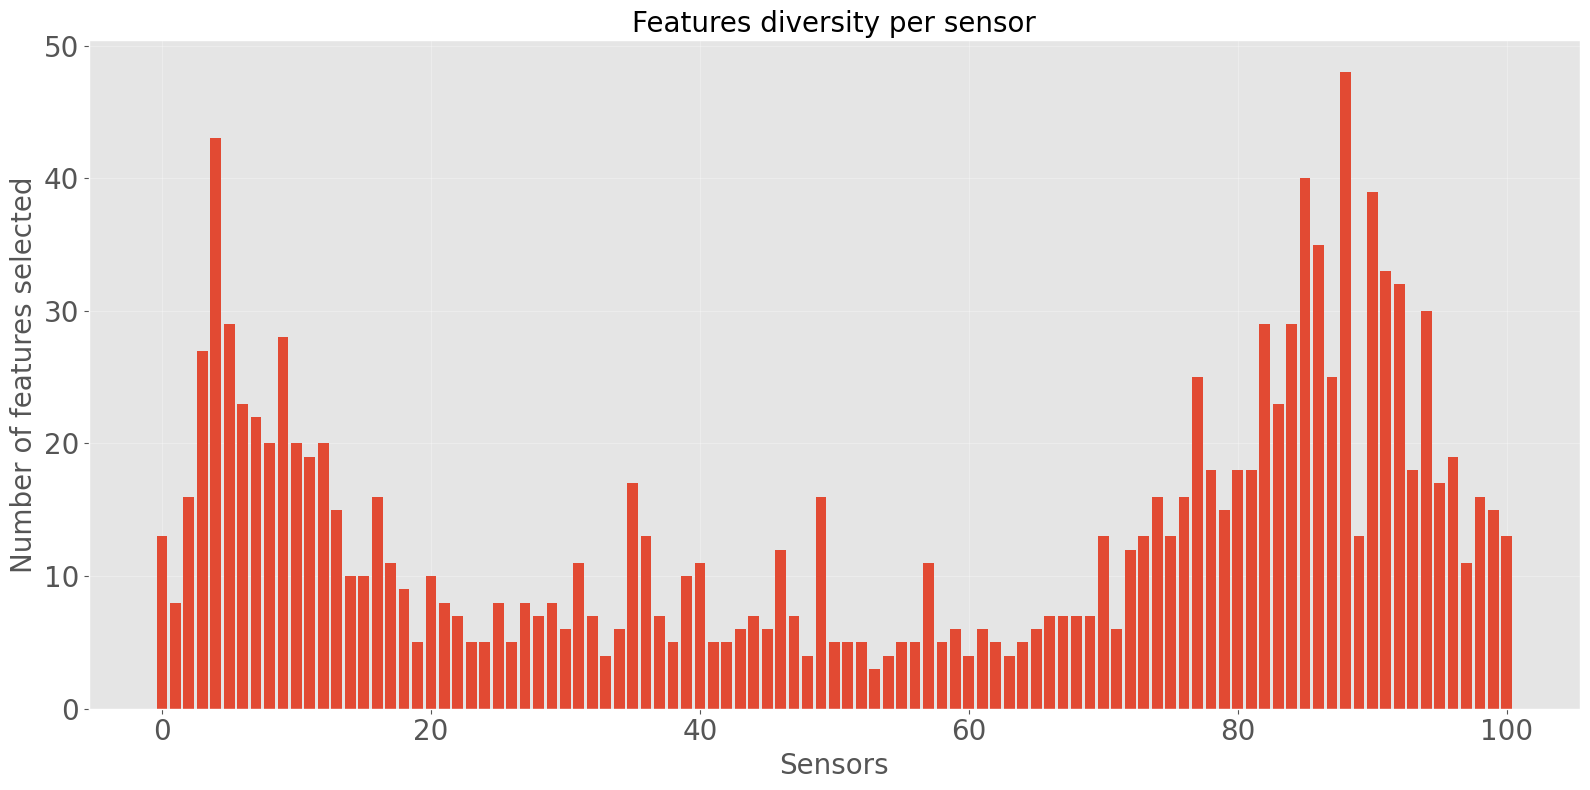

In [58]:
sensor_method_count = (
    df_long
    .groupby("sensor_id")["feature_method"]
    .nunique()
)

plt.figure(figsize=(16, 8))
plt.bar(sensor_method_count.index, sensor_method_count.values)
plt.xlabel("Sensors", fontsize=20)
plt.ylabel("Number of features selected", fontsize=20)
plt.title("Features diversity per sensor", fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

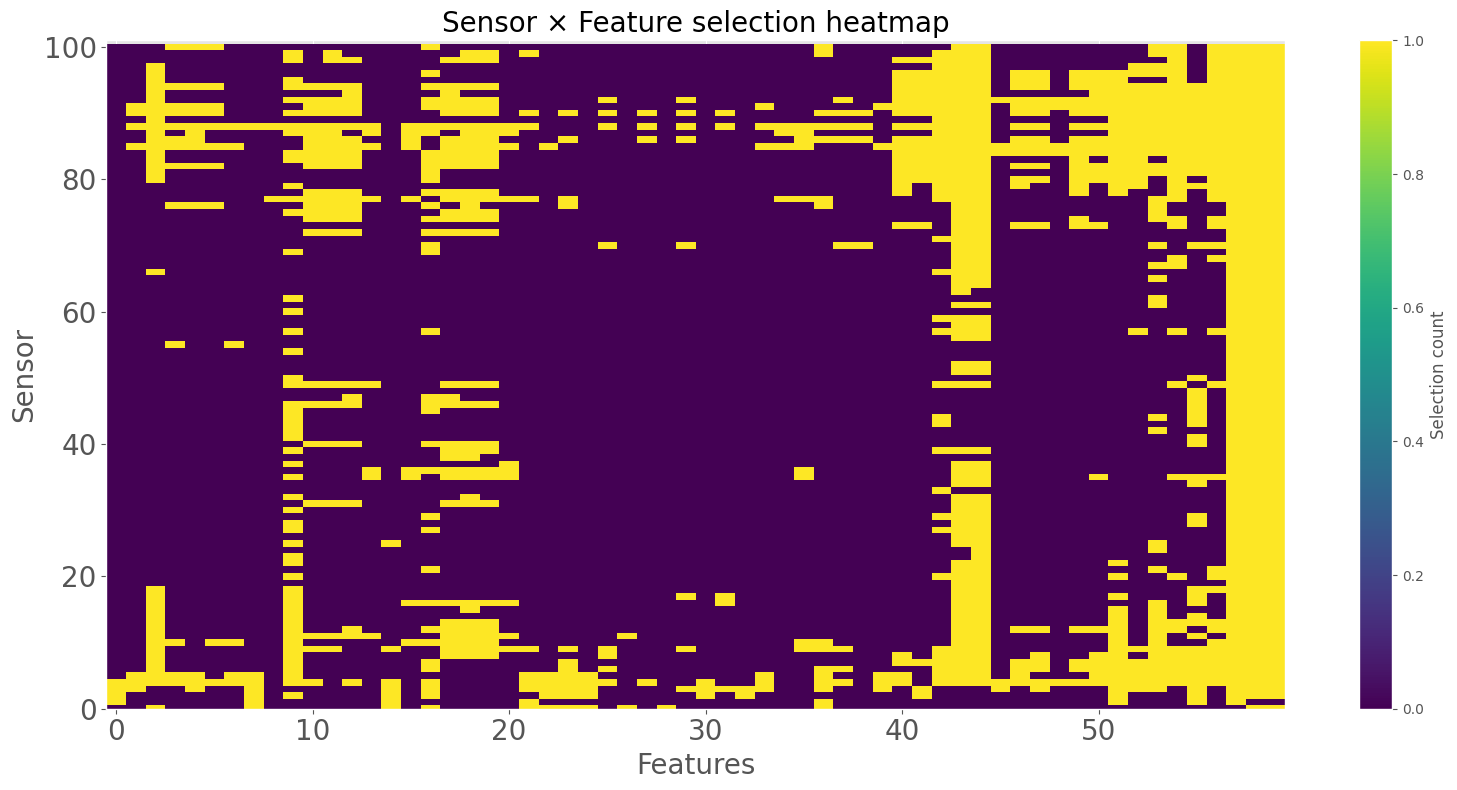

In [62]:
# Build selection matrix
selection_matrix = pd.crosstab(
    df_long["sensor_id"],
    df_long["feature_method"]
)

Z = selection_matrix.values

# Coordinates
x = np.arange(Z.shape[1])   # feature methods (0–60)
y = np.arange(Z.shape[0])   # sensors (0–101)

plt.figure(figsize=(16, 8))
pcm = plt.pcolormesh(
    x,
    y,
    Z,
    shading="nearest"
)

plt.colorbar(pcm, label="Selection count")
plt.xlabel("Features", fontsize=20)
plt.ylabel("Sensor", fontsize=20)
plt.title("Sensor × Feature selection heatmap", fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

# Ensure sensor 0 is at bottom, 100 at top
plt.ylim(0, Z.shape[0])

plt.tight_layout()
plt.show()

# pick the top 50 featues

In [64]:
method_counts = selection_matrix.sum(axis=0)

top_50_methods = (
    method_counts
    .sort_values(ascending=False)
    .head(50)
    .index
    .to_numpy()
)
top_50_methods

array([58, 59, 57, 44, 43,  9, 53, 55, 56, 42, 54, 51, 16, 18,  2, 17, 19,
       12, 52, 11, 10, 40, 50, 49, 41, 47, 46, 36,  3,  4, 23, 20,  5, 21,
       15, 35, 29, 37, 13, 25,  7,  1, 14, 22, 33,  6, 48, 31, 24, 39])

In [65]:
reduced_matrix = selection_matrix[top_50_methods]

sensor_method_counts = reduced_matrix.sum(axis=1)

sensor_method_counts.describe()

,0
count,101.000000
mean,13.356436
std,9.290408
min,3.000000
25%,6.000000
50%,11.000000
75%,18.000000
max,44.000000


In [70]:
from scipy.stats import entropy

method_entropy = selection_matrix.apply(
    lambda col: entropy(col + 1e-12), axis=0
)

top_50_entropy = method_entropy.sort_values(ascending=False).head(50)
top_50_entropy

,0
feature_method,
58,4.605170
59,4.605170
57,4.605170
44,4.369448
43,4.356709
9,3.970292
53,3.806662
55,3.784190
56,3.761200


In [71]:
score = method_counts * method_entropy
top_50_methods = score.sort_values(ascending=False).head(50).index
top_50_methods

Index([58, 59, 57, 44, 43,  9, 53, 55, 56, 42, 54, 51, 16, 18,  2, 17, 19, 12,
       52, 11, 10, 40, 50, 49, 41, 46, 47, 36,  3,  4, 23,  5, 21, 20, 15, 35,
       29, 37, 13, 25,  1,  7, 14,  6, 33, 22, 48, 31, 24, 39],
      dtype='int64', name='feature_method')